# 02b Integración de POI al grafo

**Proyecto:** accesibilidad peatonal a equipamiento urbano – Miraflores + San Juan de Miraflores (Hito 1)

Trabaja **sin red**, a partir de `data/raw/poi_osm.gpkg` (descargado en `02a`) y del grafo limpio de `01` (`data/interim/walk_graph_clean.graphml`, EPSG:32718).

Pasos:
1. Unificar cada capa de equipamiento (puntos y polígonos) en un punto representativo.
2. **Deduplicar**: un mismo establecimiento puede estar mapeado como punto y como polígono.
3. Quedarse con los POI dentro de los distritos y del buffer del grafo (los de la zona ampliada de 300–1 200 m quedan fuera del grafo; ver `docs/hito2/01_nota_ampliar_grafo.md`).
4. Asignar cada POI al **nodo más cercano** y registrar la distancia de snap.
5. Exportar y resumir.

## 1. Configuración y carga

In [1]:
import sys, json, unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import pyogrio
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src import config as cfg

np.random.seed(cfg.SEED)
CAPAS_EQUIPAMIENTO = ["salud", "educacion", "mercados"]

G = ox.load_graphml(cfg.DATA_INTERIM / "walk_graph_clean.graphml")
limites_utm = gpd.read_file(cfg.DATA_RAW / "limites_distritos.gpkg").to_crs(cfg.CRS_METRIC)
print(f"Grafo limpio: {G.number_of_nodes():,} nodos, {G.number_of_edges():,} aristas, CRS {G.graph['crs']}")

# Todas las capas del GeoPackage de POI, agrupadas por capa lógica
ruta_poi = cfg.DATA_RAW / "poi_osm.gpkg"
por_capa = {}
for layer, _ in pyogrio.list_layers(ruta_poi):
    por_capa.setdefault(layer.split("_")[0], []).append(gpd.read_file(ruta_poi, layer=layer))
poi = {c: pd.concat(v, ignore_index=True).pipe(gpd.GeoDataFrame, crs=4326).to_crs(cfg.CRS_METRIC) for c, v in por_capa.items()}
pd.DataFrame({c: {"elementos": len(g)} for c, g in poi.items()}).T

Grafo limpio: 17,265 nodos, 51,216 aristas, CRS EPSG:32718


,elementos
salud,126
educacion,748
mercados,205
parques,971
barreras,180


## 2. Punto representativo y deduplicación

- Cada elemento se reduce a un punto (`representative_point`, que cae dentro del polígono si lo hay).
- **Duplicado tipo A:** un punto que cae dentro de un polígono de la misma capa y con el mismo nombre (o alguno sin nombre) es el mismo establecimiento.
- **Duplicado tipo B:** dos elementos con el mismo nombre normalizado a menos de `DEDUP_M` m; se conserva uno (preferencia por el polígono).

In [2]:
def norm(s):
    if pd.isna(s):
        return None
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().lower().strip()
    return " ".join(s.split()) or None

def igual_o_vacio(a, b):
    return pd.isna(a) or pd.isna(b) or a == b

def deduplicar(g):
    g = g.copy()
    g["pt"] = g.geometry.representative_point()
    g["tipo_geom"] = g.geom_type          # no se guarda en el GeoPackage; se recalcula
    g["es_poligono"] = g["tipo_geom"].str.contains("Polygon")
    g["nombre_norm"] = g["name"].map(norm)

    # A: punto dentro de un polígono de la misma capa
    pol, pun = g[g["es_poligono"]], g[~g["es_poligono"]]
    dup_a = set()
    if len(pol) and len(pun):
        j = gpd.sjoin(gpd.GeoDataFrame(geometry=pun["pt"], crs=g.crs),
                      gpd.GeoDataFrame(geometry=pol.geometry, crs=g.crs), how="inner", predicate="within")
        for i_punto, i_pol in zip(j.index, j["index_right"]):
            if igual_o_vacio(g.at[i_punto, "nombre_norm"], g.at[i_pol, "nombre_norm"]):
                dup_a.add(i_punto)
    resto = g.drop(index=list(dup_a))

    # B: mismo nombre a menos de DEDUP_M m (polígonos primero)
    resto = resto.sort_values("es_poligono", ascending=False)
    dup_b = set()
    for _, grp in resto[resto["nombre_norm"].notna()].groupby("nombre_norm"):
        guardados = []
        for i, fila in grp.iterrows():
            if any(fila["pt"].distance(q) <= cfg.DEDUP_M for q in guardados):
                dup_b.add(i)
            else:
                guardados.append(fila["pt"])
    final = resto.drop(index=list(dup_b))
    final = final.set_geometry("pt").drop(columns="geometry").rename_geometry("geometry")
    return final, len(dup_a), len(dup_b)

limpios, filas = {}, []
for capa in CAPAS_EQUIPAMIENTO:
    g, a, b = deduplicar(poi[capa])
    g["capa"] = capa
    limpios[capa] = g
    filas.append({"capa": capa, "brutos": len(poi[capa]), "dup. punto-en-polígono": a, "dup. mismo nombre": b, "únicos": len(g)})
tabla_dedup = pd.DataFrame(filas).set_index("capa")
tabla_dedup

,brutos,dup. punto-en-polígono,dup. mismo nombre,únicos
capa,,,,
salud,126,0,0,126
educacion,748,8,6,734
mercados,205,0,2,203


## 3. Selección espacial

Se conservan los POI de Miraflores, San Juan de Miraflores y del buffer de 300 m del grafo. Los de la zona ampliada (300–1 200 m) se descartan para este análisis: no tienen nodos cercanos en el grafo.

In [3]:
equip = pd.concat(limpios.values(), ignore_index=True)
equip = gpd.GeoDataFrame(equip, geometry="geometry", crs=cfg.CRS_METRIC)
en_grafo = ~equip["zona"].str.startswith("Zona ampliada")
print(f"POI únicos: {len(equip)} | dentro del alcance del grafo: {en_grafo.sum()} | zona ampliada (descartados): {(~en_grafo).sum()}")
equip = equip[en_grafo].reset_index(drop=True)
pd.crosstab(equip["capa"], equip["zona"], margins=True)

POI únicos: 1063 | dentro del alcance del grafo: 588 | zona ampliada (descartados): 475


zona,Buffer (≤ 300 m),Miraflores,San Juan de Miraflores,All
capa,,,,
educacion,62,63,287,412
mercados,21,30,51,102
salud,20,30,24,74
All,103,123,362,588


## 4. Integración al grafo: nodo más cercano

`ox.nearest_nodes` sobre el grafo proyectado (distancias euclídeas en metros). Se registra la distancia de snap; los POI a más de `SNAP_MAX_M` m de su nodo se marcan como no válidos, porque probablemente no están conectados a la red (p. ej. falta de vías en OSM).

In [4]:
nodos = ox.graph_to_gdfs(G, edges=False)
equip["nodo_osmid"] = ox.nearest_nodes(G, X=equip.geometry.x.values, Y=equip.geometry.y.values)
xy = nodos.loc[equip["nodo_osmid"], ["x", "y"]].to_numpy()
equip["dist_snap_m"] = np.hypot(equip.geometry.x.values - xy[:, 0], equip.geometry.y.values - xy[:, 1])
equip["snap_valido"] = equip["dist_snap_m"] <= cfg.SNAP_MAX_M
equip["distrito_nodo"] = nodos.loc[equip["nodo_osmid"], "distrito"].to_numpy()

print(f"Distancia de snap (m) por capa:")
display_tab = equip.groupby("capa")["dist_snap_m"].describe(percentiles=[.5, .9]).round(1)
print(display_tab.to_string())
print(f"\nPOI con snap > {cfg.SNAP_MAX_M} m (no válidos): {(~equip['snap_valido']).sum()} de {len(equip)}")
equip.loc[~equip["snap_valido"], ["capa", "categoria", "name", "zona", "dist_snap_m"]].sort_values("dist_snap_m", ascending=False).head(10).round(1)

Distancia de snap (m) por capa:
           count  mean   std   min   50%   90%    max
capa                                                 
educacion  412.0  34.0  21.4   2.0  29.3  58.6  255.0
mercados   102.0  30.8  13.0   1.1  29.3  46.9   71.1
salud       74.0  31.0  13.2  10.6  28.9  47.9   65.7

POI con snap > 100 m (no válidos): 5 de 588


,capa,categoria,name,zona,dist_snap_m
137,educacion,school,Colegio de La Inmaculada,Buffer (≤ 300 m),255.0
214,educacion,school,Colegio Padre Iluminato,San Juan de Miraflores,117.7
111,educacion,school,Colegio Manuel Ramirez Barinaga,San Juan de Miraflores,113.9
163,educacion,school,Institución Educativa 7229 La Merced De Lima,San Juan de Miraflores,107.6
131,educacion,school,C.E.B.E. Medalla Milagrosa,Buffer (≤ 300 m),104.8


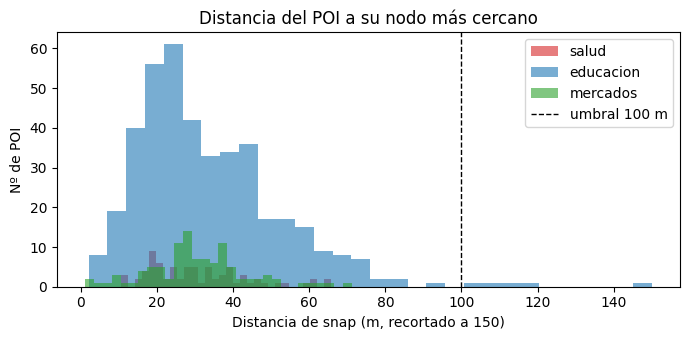

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for capa, color in {"salud": "#d62728", "educacion": "#1f77b4", "mercados": "#2ca02c"}.items():
    ax.hist(equip.loc[equip["capa"] == capa, "dist_snap_m"].clip(upper=150), bins=30, alpha=0.6, color=color, label=capa)
ax.axvline(cfg.SNAP_MAX_M, color="k", ls="--", lw=1, label=f"umbral {cfg.SNAP_MAX_M} m")
ax.set_xlabel("Distancia de snap (m, recortado a 150)")
ax.set_ylabel("Nº de POI")
ax.legend()
ax.set_title("Distancia del POI a su nodo más cercano")
plt.tight_layout()
plt.show()

### Resumen de POI integrados

In [6]:
validos = equip[equip["snap_valido"]]
resumen = (validos.groupby(["capa", "zona"]).agg(poi=("capa", "size"), nodos_unicos=("nodo_osmid", "nunique"))
           .unstack(fill_value=0))
print("POI válidos por capa y zona (y nodos distintos a los que se asignan):")
print(resumen.to_string())
print()
print("Nodos distintos por capa:", validos.groupby("capa")["nodo_osmid"].nunique().to_dict())
print("Salud por categoría:", validos.loc[validos["capa"] == "salud", "categoria"].value_counts().to_dict())

POI válidos por capa y zona (y nodos distintos a los que se asignan):
                       poi                                       nodos_unicos                                  
zona      Buffer (≤ 300 m) Miraflores San Juan de Miraflores Buffer (≤ 300 m) Miraflores San Juan de Miraflores
capa                                                                                                           
educacion               60         63                    284               55         59                    250
mercados                21         30                     51               20         30                     50
salud                   20         30                     24               18         29                     23

Nodos distintos por capa: {'educacion': 364, 'mercados': 100, 'salud': 70}
Salud por categoría: {'clinic': 65, 'hospital': 8, 'centre': 1}


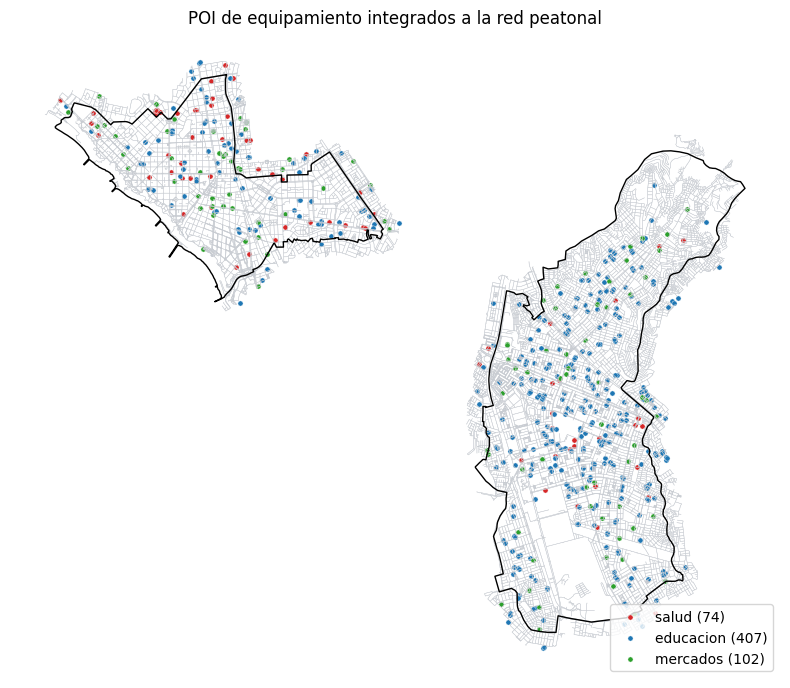

In [7]:
aristas = ox.graph_to_gdfs(G, nodes=False)
colores = {"salud": "#d62728", "educacion": "#1f77b4", "mercados": "#2ca02c"}
fig, ax = plt.subplots(figsize=(8, 8))
aristas.plot(ax=ax, color="#c8ccd2", linewidth=0.3)
limites_utm.boundary.plot(ax=ax, color="k", lw=1)
for capa, color in colores.items():
    v = validos[validos["capa"] == capa]
    v.plot(ax=ax, color=color, markersize=14, label=f"{capa} ({len(v)})", edgecolor="white", linewidth=0.3)
ax.legend(loc="lower right")
ax.set_title("POI de equipamiento integrados a la red peatonal")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 5. Exportación

- `data/processed/poi_snap.gpkg` (con geometría) y `data/processed/poi_snap.csv` (tabla, sin geometría).
- `data/processed/poi_resumen.csv`: conteos por capa y zona tras deduplicar y asignar.

In [8]:
cols = ["capa", "categoria", "name", "element", "id", "zona", "nodo_osmid", "distrito_nodo", "dist_snap_m", "snap_valido", "geometry"]
out = equip[[c for c in cols if c in equip.columns]].copy()
out.to_file(cfg.DATA_PROCESSED / "poi_snap.gpkg", layer="poi", driver="GPKG")
tabla = out.drop(columns="geometry").assign(x=out.geometry.x.round(1), y=out.geometry.y.round(1))
tabla.to_csv(cfg.DATA_PROCESSED / "poi_snap.csv", index=False)

resumen_csv = (tabla_dedup.join(equip.groupby("capa").size().rename("en_alcance_del_grafo"))
               .join(validos.groupby("capa").size().rename("snap_valido")))
resumen_csv.to_csv(cfg.DATA_PROCESSED / "poi_resumen.csv")
resumen_csv

,brutos,dup. punto-en-polígono,dup. mismo nombre,únicos,en_alcance_del_grafo,snap_valido
capa,,,,,,
salud,126,0,0,126,74,74
educacion,748,8,6,734,412,407
mercados,205,0,2,203,102,102


### Hallazgos de la integración

- **Deduplicación:** pocos duplicados reales: 14 en educación (8 punto-en-polígono y 6 por nombre), 2 en mercados y ninguno en salud. En salud no hay puntos dentro de polígonos con el mismo nombre; los 47 puntos y 78 polígonos corresponden a establecimientos distintos (o con nombres distintos), así que no se fusionan sin más. Los casos dudosos se revisarán en el análisis exploratorio.
- **Alcance del grafo:** de 1 063 POI únicos, 588 caen dentro de los distritos o del buffer de 300 m; los 475 restantes (zona ampliada) quedan fuera del grafo (ver `docs/hito2/01_nota_ampliar_grafo.md`).
- **Snap:** la distancia al nodo más cercano tiene mediana ≈ 29 m y percentil 90 ≈ 59 m (máx. 255 m). Solo 5 POI, todos colegios (3 en SJM y 2 en el buffer), superan los 100 m y se marcan como no válidos; quedan **583 POI válidos**: 74 de salud, 407 de educación y 102 de mercados.
- **Salud:** 65 `clinic`, 8 `hospital` y 1 `centre`. Hay muy pocos hospitales (4 en Miraflores, 3 en SJM y 1 en el buffer), por lo que el análisis de salud debe considerar también las clínicas y distinguirlas por categoría.
- **Contraste entre distritos:** SJM concentra 284 colegios válidos frente a 63 en Miraflores. Los conteos absolutos no son comparables: hay que normalizar por área (y, en el Hito 2, por población).
- **Nodos compartidos:** varios POI se asignan al mismo nodo (364 nodos distintos para 407 colegios, 70 para 74 de salud), lo que se tendrá en cuenta al calcular la cobertura por nodos.